<h3>Happy Customers</h3>

<h4>Notebook 2</h4>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bespoke functions
from model_evaluation import *
from data_prep import *
from save_model import *

In [ ]:
X,Y = generate_XY()
X_train_scaled, X_test_scaled, Y_train, Y_test = split_scale_data(X=X,Y=Y,stratify=Y["Y"],test_size=0.3)

<h4>Grid Search 1</h4>

In [ ]:
# Using GridSearchCV and Stratified K-folds for hyperparameter tuning of sklearn LR model.


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

model = LogisticRegression(max_iter=1000,random_state=13)


param_grid = [
    {
        "solver": ["lbfgs"],
        "penalty": ["l2"],
        "C": [0.001, 0.01, 0.1, 1, 10, 100],
        "class_weight": [None, "balanced"]
    },
    {
        "solver": ["liblinear"],
        "penalty": ["l1", "l2"],
        "C": [0.001, 0.01, 0.1, 1, 10, 100],
        "class_weight": [None, "balanced"]
    },
    {
        "solver": ["saga"],
        "penalty": ["l1", "l2"],
        "C": [0.001, 0.01, 0.1, 1, 10, 100],
        "class_weight": [None, "balanced"]
    }
]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=13
)

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="f1",      # good if classes are imbalanced
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, Y_train)

print("Best parameters:")
print(grid.best_params_)

print("Best CV F1 score:")
print(grid.best_score_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters:
{'C': 0.001, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1 score:
0.7054945054945054


c:\Users\cochr\Data Science Projects\Happy Customers\Happy Customers\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [4]:
# Take the 'optimised' model and making some predictions:

# Predict off Model 1:
Y_pred_grid = grid.predict(X_test_scaled)
Y_proba_grid = grid.predict_proba(X_test_scaled)[:,1] # '1' label (positive class) probabilities for plotting ROC-AUC curve.
grid_eval = evaluate_binary_classifier(Y_test,Y_pred_grid,Y_proba_grid)


===== Binary Classification Evaluation =====

Accuracy: 0.5526
Balanced Accuracy: 0.5000
Precision: 0.5526
Recall: 1.0000
F1 Score: 0.7119
Matthews Corrcoef: 0.0000
ROC AUC: 0.6022
Log Loss: 0.6862

Confusion Matrix:
[[ 0 17]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.55      1.00      0.71        21

    accuracy                           0.55        38
   macro avg       0.28      0.50      0.36        38
weighted avg       0.31      0.55      0.39        38



c:\Users\cochr\Data Science Projects\Happy Customers\Happy Customers\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cochr\Data Science Projects\Happy Customers\Happy Customers\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cochr\Data Science Projects\Happy Customers\Happy Customers\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_d

- Everything is being predicted as 1.
- Precision and recall for the negative class is 0.
- How to fix this?

In [5]:
Y_proba_grid

array([0.54515129, 0.54246493, 0.54244726, 0.55228615, 0.54624733,
       0.5495568 , 0.54700171, 0.54427371, 0.54247525, 0.54194605,
       0.55091595, 0.54505392, 0.54256402, 0.54495225, 0.54562865,
       0.53774811, 0.54891097, 0.54405531, 0.54380843, 0.55033975,
       0.54587802, 0.53976111, 0.55033975, 0.54827366, 0.54200368,
       0.53946336, 0.54709034, 0.54587802, 0.54001547, 0.54973387,
       0.54530069, 0.55025124, 0.54691309, 0.5507685 , 0.54380843,
       0.54964533, 0.54271193, 0.54623701])

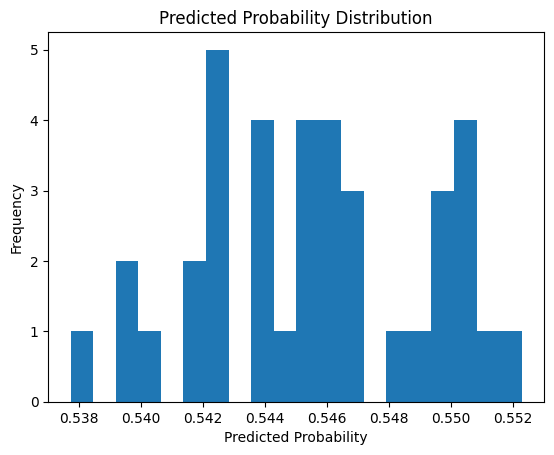

In [6]:
plt.hist(Y_proba_grid, bins=20)
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Predicted Probability Distribution")
plt.show()

- All probabilities are above 0.5 and within a very narrow range.
- Threshold is therefore an issue.
- Is regularisation an issue too?

In [7]:
print(grid.best_estimator_.coef_)

[[0.01188416 0.00035766 0.00798786 0.00261299 0.00608802 0.00541431]]


- The model has tiny coefficients -> Over-regularisation.

<h4>Grid Search 2</h4>

- Fixing the over-regularisation.
- Providing less 'small' options for C to the parameter grid used by the GridSearchCV algorithm.

In [10]:
model_2 = LogisticRegression(max_iter=1000,random_state=13)


param_grid_2 = [
    {
        "solver": ["lbfgs"],
        "penalty": ["l2"],
        "C": [0.01, 0.05, 0.1, 0.5, 1, 5, 10],
        "class_weight": [None, "balanced"]
    }
]

cv_2 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=13
)

grid_2 = GridSearchCV(
    estimator=model_2,
    param_grid=param_grid_2,
    scoring="f1",      # good if classes are imbalanced
    cv=cv_2,
    n_jobs=-1,
    verbose=1
)

grid_2.fit(X_train_scaled, Y_train)

print("Best parameters:")
print(grid_2.best_params_)

print("Best CV F1 score:")
print(grid_2.best_score_)

Y_pred_grid_2 = grid_2.predict(X_test_scaled)
Y_proba_grid_2 = grid_2.predict_proba(X_test_scaled)[:,1] 
grid_2_eval = evaluate_binary_classifier(Y_test,Y_pred_grid_2,Y_proba_grid_2)

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best parameters:
{'C': 0.01, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1 score:
0.6981481481481481

===== Binary Classification Evaluation =====

Accuracy: 0.5526
Balanced Accuracy: 0.5112
Precision: 0.5588
Recall: 0.9048
F1 Score: 0.6909
Matthews Corrcoef: 0.0363
ROC AUC: 0.5994
Log Loss: 0.6774

Confusion Matrix:
[[ 2 15]
 [ 2 19]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.12      0.19        17
           1       0.56      0.90      0.69        21

    accuracy                           0.55        38
   macro avg       0.53      0.51      0.44        38
weighted avg       0.53      0.55      0.47        38



c:\Users\cochr\Data Science Projects\Happy Customers\Happy Customers\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


- Increase the precision and recall of the negative class at the expense of F1-score

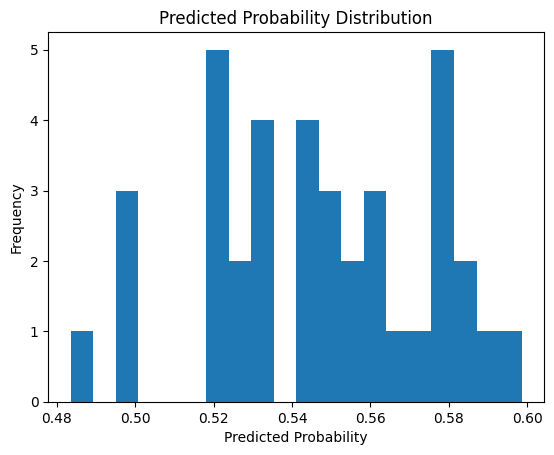

In [11]:
plt.hist(Y_proba_grid_2, bins=20)
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Predicted Probability Distribution")
plt.show()

- Probability range of the predictions has increase relative to the over-regularised model.